LAB02 - Tarefa 01

Baixar uma base de dados que foi adaptada de um órgão da ONU sobre dados relacionados a diversos países, como qualidade de vida, índice relacionado a percepção de corrupção, entre diversos outros. Para trabalhar nesta tarefa baixar o arquivo DadosWH.csv disponibilizado no Moodle. Vamos agora implementar o algoritmo k-means usando a biblioteca sckit-learn para agrupar os dados da base de dados disponibilizada. Para isso baixar o arquivo Lab02Tarefa01 disponibilizado na nossa Comunidade da disciplina no Moodle©.

In [12]:
# Importa as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import numpy as np

In [13]:
# Carrega minha pasta do GoogleDrive onde está localizada a base de dados
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
dados = pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Aula02 - k-means e k-medoids/DadosWH.csv')
dados

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
0,Afghanistan,Asia,2010,29185507.0,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
1,Afghanistan,Asia,2011,30117413.0,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
2,Afghanistan,Asia,2012,31161376.0,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
3,Afghanistan,Asia,2013,32269589.0,3.572,7.725,0.484,52.56,0.578,0.061,0.823,0.621,0.273
4,Afghanistan,Asia,2014,33370794.0,3.131,7.718,0.526,52.88,0.509,0.104,0.871,0.532,0.375
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215,Zimbabwe,Africa,2015,13814629.0,3.703,7.992,0.736,53.80,0.667,-0.123,0.810,0.715,0.179
1216,Zimbabwe,Africa,2016,14030390.0,3.735,7.984,0.768,54.40,0.733,-0.095,0.724,0.738,0.209
1217,Zimbabwe,Africa,2017,14236745.0,3.638,8.016,0.754,55.00,0.753,-0.098,0.751,0.806,0.224
1218,Zimbabwe,Africa,2018,14439018.0,3.616,8.049,0.775,55.60,0.763,-0.068,0.844,0.710,0.212


In [15]:
dados = pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Aula02 - k-means e k-medoids/DadosWH.csv')
MB = dados.year == 2019
dados2019 = dados[MB]

In [16]:
dados2019

,Name,Continent,year,population,Life_Ladder,Log_GDP_per_capita,Social_support,Healthy_life_expectancy_at_birth,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Positive_affect,Negative_affect
9,Afghanistan,Asia,2019,38041754.0,2.375,7.697,0.420,52.4,0.394,-0.108,0.924,0.351,0.502
19,Albania,Europe,2019,2854191.0,4.995,9.544,0.686,69.0,0.777,-0.099,0.914,0.681,0.274
29,Algeria,Africa,2019,43053054.0,4.745,9.337,0.803,66.1,0.385,0.005,0.741,0.585,0.215
39,Argentina,South America,2019,44938712.0,6.086,10.000,0.896,69.0,0.817,-0.211,0.830,0.826,0.319
49,Armenia,Europe,2019,2957731.0,5.488,9.522,0.782,67.2,0.844,-0.172,0.583,0.598,0.430
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,Uruguay,South America,2019,3461734.0,6.600,9.979,0.933,69.1,0.903,-0.095,0.599,0.889,0.222
1189,Uzbekistan,Asia,2019,33580650.0,6.154,8.853,0.915,65.4,0.970,0.304,0.511,0.845,0.220
1199,Vietnam,Asia,2019,96462106.0,5.467,8.992,0.848,68.1,0.952,-0.126,0.788,0.751,0.186
1209,Zambia,Africa,2019,17861030.0,3.307,8.155,0.638,55.8,0.811,0.077,0.832,0.743,0.394


<Axes: xlabel='Perceptions_of_corruption', ylabel='Life_Ladder'>

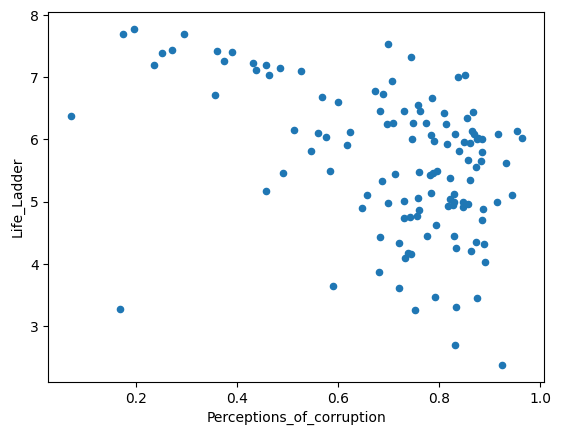

In [17]:
dados2019.plot.scatter(x='Perceptions_of_corruption',y='Life_Ladder')

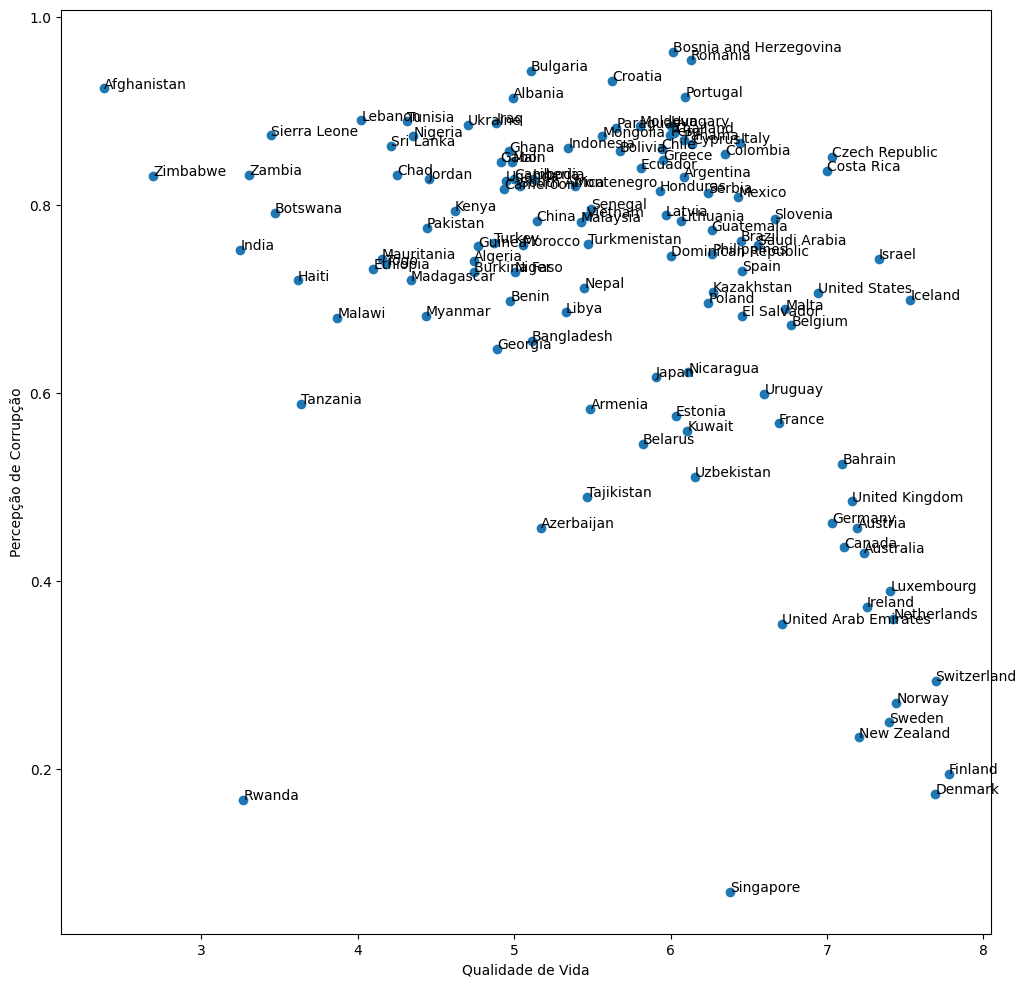

In [18]:
plt.figure(figsize=(12,12))
plt.scatter(dados2019.Life_Ladder, dados2019.Perceptions_of_corruption)
for _, row in dados2019.iterrows():
    plt.annotate(row.Name, (row.Life_Ladder, row.Perceptions_of_corruption))
plt.xlabel('Qualidade de Vida')
plt.ylabel('Percepção de Corrupção')
plt.show()

In [19]:
from sklearn.cluster import KMeans
dimensoes = ['Life_Ladder','Perceptions_of_corruption']
Xs = dados2019[dimensoes]
kmeans = KMeans(n_clusters=6)
kmeans.fit(Xs)

KMeans(n_clusters=6)

In [20]:
for i in range(6):
    MB = kmeans.labels_==i
    print('Cluster {}: {}'.format(i,dados2019[MB].Name.values))

Cluster 0: ['Australia' 'Austria' 'Bahrain' 'Canada' 'Denmark' 'Finland' 'Germany'
 'Iceland' 'Ireland' 'Israel' 'Luxembourg' 'Netherlands' 'New Zealand'
 'Norway' 'Sweden' 'Switzerland' 'United Kingdom']
Cluster 1: ['Albania' 'Armenia' 'Azerbaijan' 'Bangladesh' 'Benin' 'Bulgaria'
 'Cambodia' 'Cameroon' 'China' 'Gabon' 'Georgia' 'Ghana' 'Indonesia'
 'Iraq' 'Liberia' 'Libya' 'Malaysia' 'Mali' 'Mongolia' 'Montenegro'
 'Morocco' 'Nepal' 'Niger' 'Senegal' 'South Africa' 'Tajikistan' 'Turkey'
 'Turkmenistan' 'Uganda' 'Vietnam']
Cluster 2: ['Afghanistan' 'Botswana' 'Haiti' 'India' 'Rwanda' 'Sierra Leone'
 'Tanzania' 'Zambia' 'Zimbabwe']
Cluster 3: ['Argentina' 'Belarus' 'Bolivia' 'Bosnia and Herzegovina' 'Chile'
 'Colombia' 'Croatia' 'Cyprus' 'Dominican Republic' 'Ecuador' 'Estonia'
 'Greece' 'Guatemala' 'Honduras' 'Hungary' 'Japan' 'Kazakhstan' 'Kuwait'
 'Latvia' 'Lithuania' 'Moldova' 'Nicaragua' 'Panama' 'Paraguay' 'Peru'
 'Philippines' 'Poland' 'Portugal' 'Romania' 'Serbia' 'Thailand'
 'U

In [21]:
from sklearn.cluster import KMeans
dimensoes = ['Life_Ladder','Perceptions_of_corruption']
Xs = dados2019[dimensoes]
kmeans = KMeans(n_clusters=6)
kmeans.fit(Xs)
for i in range(6):
    MB = kmeans.labels_==i
    print('Cluster {}: {}'.format(i,dados2019[MB].Name.values))

Cluster 0: ['Albania' 'Algeria' 'Armenia' 'Azerbaijan' 'Bangladesh' 'Benin'
 'Bulgaria' 'Burkina Faso' 'Cambodia' 'Cameroon' 'China' 'Gabon' 'Georgia'
 'Ghana' 'Guinea' 'Indonesia' 'Iraq' 'Liberia' 'Libya' 'Malaysia' 'Mali'
 'Mongolia' 'Montenegro' 'Morocco' 'Nepal' 'Niger' 'Senegal'
 'South Africa' 'Tajikistan' 'Turkey' 'Turkmenistan' 'Uganda' 'Vietnam']
Cluster 1: ['Belgium' 'Brazil' 'Costa Rica' 'Czech Republic' 'El Salvador' 'France'
 'Italy' 'Malta' 'Mexico' 'Saudi Arabia' 'Singapore' 'Slovenia' 'Spain'
 'United Arab Emirates' 'United States' 'Uruguay']
Cluster 2: ['Afghanistan' 'Botswana' 'Haiti' 'India' 'Rwanda' 'Sierra Leone'
 'Tanzania' 'Zambia' 'Zimbabwe']
Cluster 3: ['Argentina' 'Belarus' 'Bolivia' 'Bosnia and Herzegovina' 'Chile'
 'Colombia' 'Croatia' 'Cyprus' 'Dominican Republic' 'Ecuador' 'Estonia'
 'Greece' 'Guatemala' 'Honduras' 'Hungary' 'Japan' 'Kazakhstan' 'Kuwait'
 'Latvia' 'Lithuania' 'Moldova' 'Nicaragua' 'Panama' 'Paraguay' 'Peru'
 'Philippines' 'Poland' 'Portuga

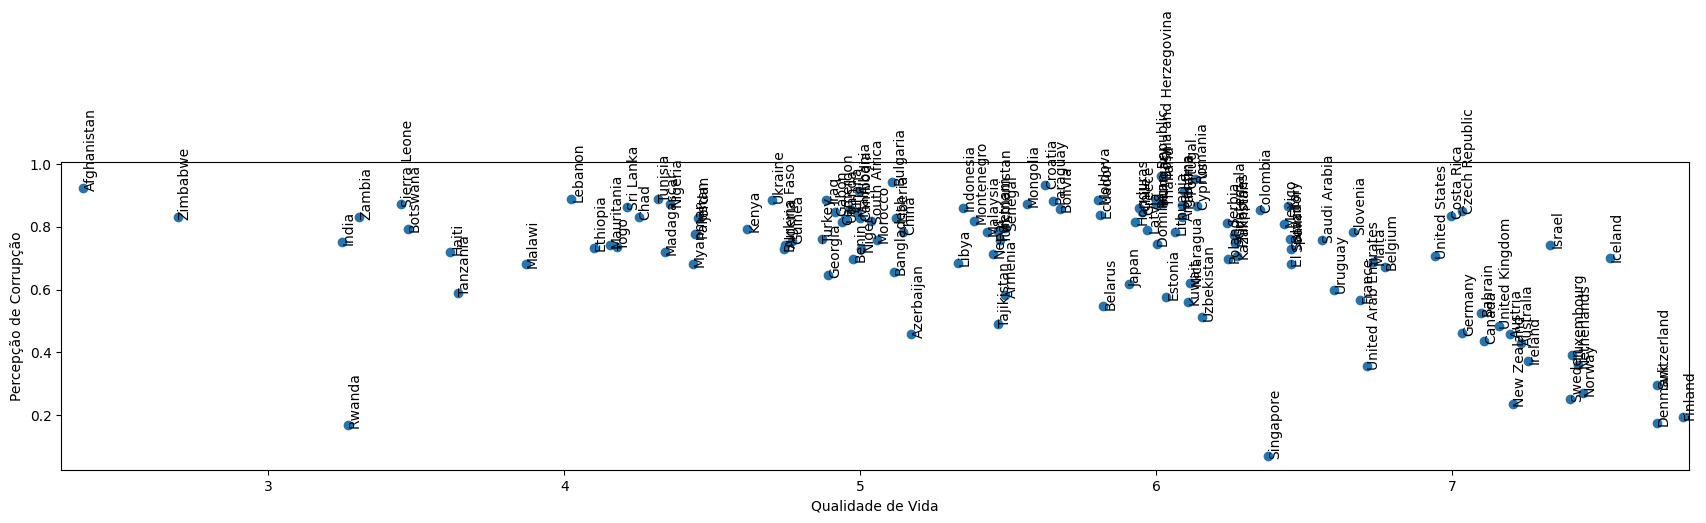

In [22]:
plt.figure(figsize=(21,4))
plt.scatter(dados2019.Life_Ladder, dados2019.Perceptions_of_corruption)
for _, x in dados2019.iterrows():
    plt.annotate(x.Name, (x.Life_Ladder, x.Perceptions_of_corruption),rotation=90)
plt.xlim([2.3,7.8])
plt.xlabel('Qualidade de Vida')
plt.ylabel('Percepção de Corrupção')
plt.show()

In [23]:
dimensoes = ['Life_Ladder','Perceptions_of_corruption']
Xs = dados2019[dimensoes]
Xs = (Xs - Xs.min())/(Xs.max()-Xs.min())
kmeans = KMeans(n_clusters=6)
kmeans.fit(Xs)
for i in range(6):
    MB = kmeans.labels_==i
    print('Cluster {}: {}'.format(i,dados2019[MB].Name.values))

Cluster 0: ['Afghanistan' 'Botswana' 'Ethiopia' 'Haiti' 'India' 'Lebanon' 'Malawi'
 'Mauritania' 'Sierra Leone' 'Tanzania' 'Togo' 'Zambia' 'Zimbabwe']
Cluster 1: ['Argentina' 'Bolivia' 'Bosnia and Herzegovina' 'Brazil' 'Chile'
 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Dominican Republic' 'Ecuador' 'Greece' 'Guatemala' 'Honduras' 'Hungary'
 'Italy' 'Latvia' 'Lithuania' 'Mexico' 'Moldova' 'Mongolia' 'Panama'
 'Paraguay' 'Peru' 'Philippines' 'Portugal' 'Romania' 'Saudi Arabia'
 'Serbia' 'Slovenia' 'Thailand']
Cluster 2: ['Australia' 'Austria' 'Canada' 'Denmark' 'Finland' 'Germany' 'Ireland'
 'Luxembourg' 'Netherlands' 'New Zealand' 'Norway' 'Singapore' 'Sweden'
 'Switzerland' 'United Arab Emirates' 'United Kingdom']
Cluster 3: ['Armenia' 'Azerbaijan' 'Bahrain' 'Belarus' 'Belgium' 'El Salvador'
 'Estonia' 'France' 'Iceland' 'Israel' 'Japan' 'Kazakhstan' 'Kuwait'
 'Malta' 'Nicaragua' 'Poland' 'Spain' 'Tajikistan' 'United States'
 'Uruguay' 'Uzbekistan']
Cluster 4: ['Alb

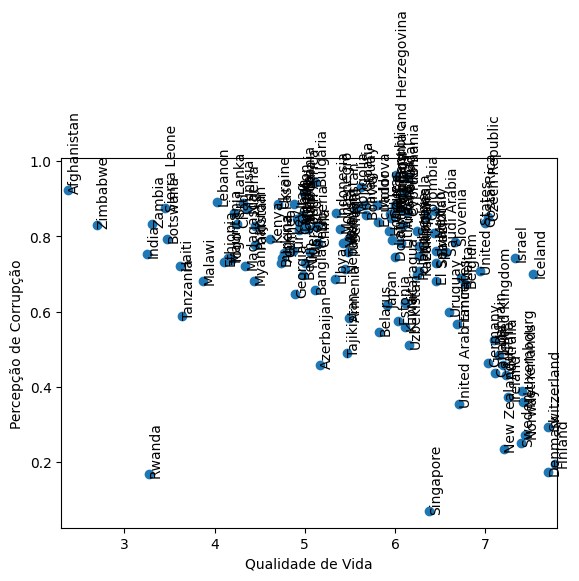

In [24]:
plt.scatter(dados2019.Life_Ladder, dados2019.Perceptions_of_corruption)
for _, x in dados2019.iterrows():
    plt.annotate(x.Name, (x.Life_Ladder, x.Perceptions_of_corruption),rotation=90)
plt.xlim([2.3,7.8])
plt.xlabel('Qualidade de Vida')
plt.ylabel('Percepção de Corrupção')
plt.show()

In [25]:
dados2019 = dados2019.copy()
dados2019['Cluster'] = kmeans.labels_
print(dados2019.head())

           Name      Continent  year  population  Life_Ladder  \
9   Afghanistan           Asia  2019  38041754.0        2.375   
19      Albania         Europe  2019   2854191.0        4.995   
29      Algeria         Africa  2019  43053054.0        4.745   
39    Argentina  South America  2019  44938712.0        6.086   
49      Armenia         Europe  2019   2957731.0        5.488   

    Log_GDP_per_capita  Social_support  Healthy_life_expectancy_at_birth  \
9                7.697           0.420                              52.4   
19               9.544           0.686                              69.0   
29               9.337           0.803                              66.1   
39              10.000           0.896                              69.0   
49               9.522           0.782                              67.2   

    Freedom_to_make_life_choices  Generosity  Perceptions_of_corruption  \
9                          0.394      -0.108                      0.924   
19

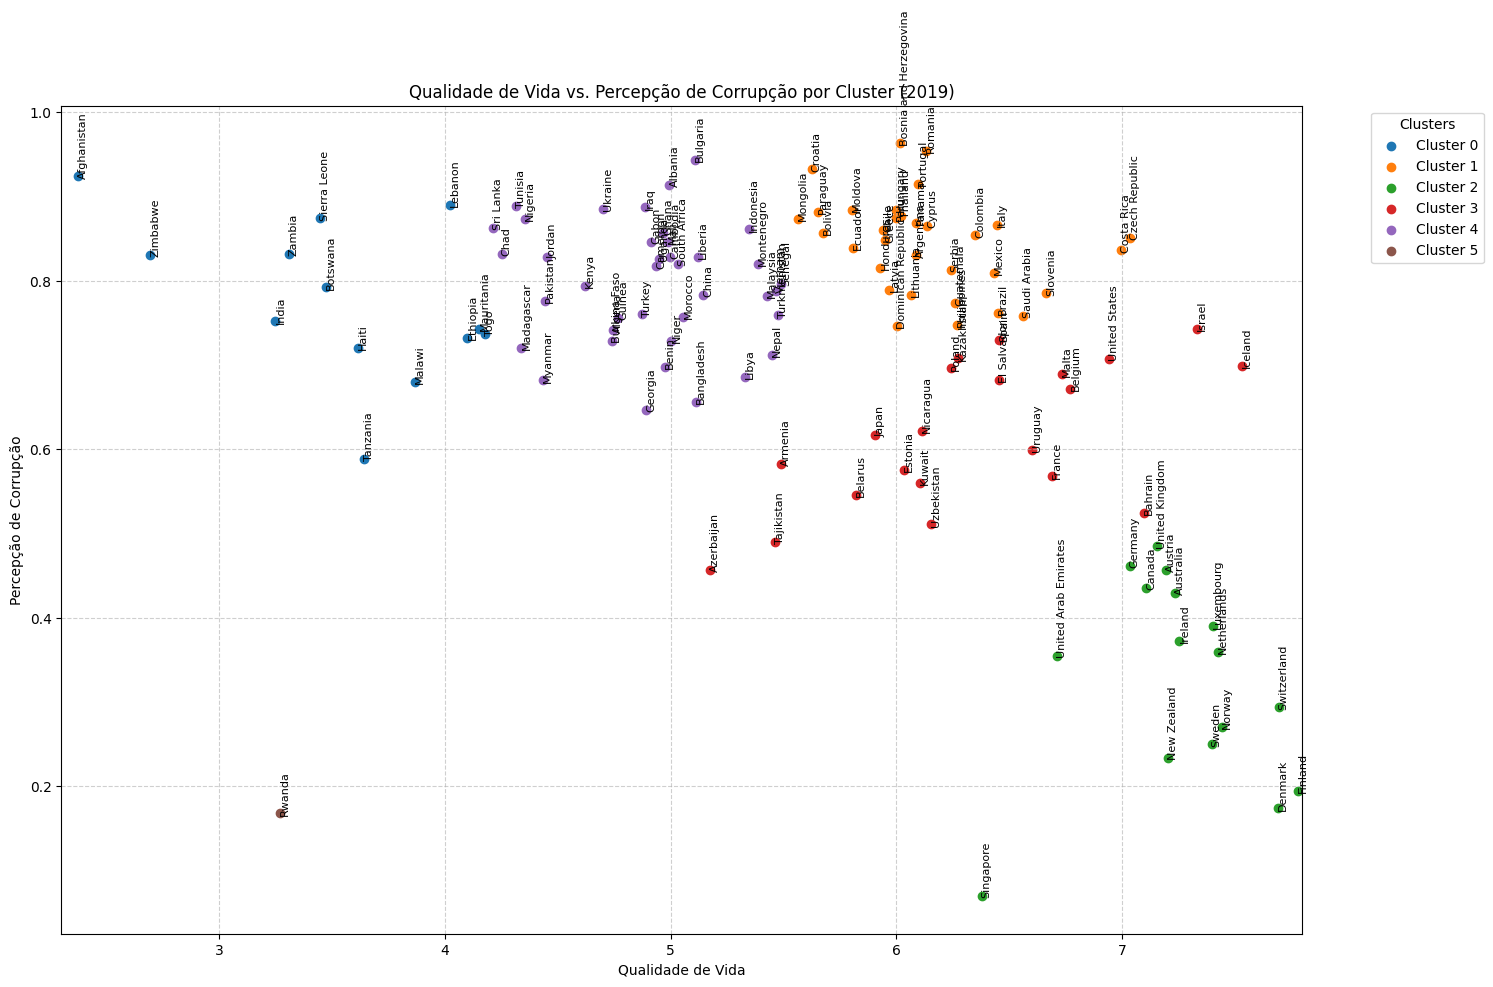

In [26]:
plt.figure(figsize=(15, 10))

for cluster_id in sorted(dados2019['Cluster'].unique()):
    cluster_data = dados2019[dados2019['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Life_Ladder'], cluster_data['Perceptions_of_corruption'], label=f'Cluster {cluster_id}')

for _, row in dados2019.iterrows():
    plt.annotate(row['Name'], (row['Life_Ladder'], row['Perceptions_of_corruption']), rotation=90, fontsize=8)

plt.xlim([2.3, 7.8])
plt.xlabel('Qualidade de Vida')
plt.ylabel('Percepção de Corrupção')
plt.title('Qualidade de Vida vs. Percepção de Corrupção por Cluster (2019)')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()